# **Primero hay que hacer lo inicial**

Eso implica indicar los imports necesario

In [4]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
x, p = sp.symbols('x p')

# En el punto 1 se pide que se arme las funciones de demanda y de la oferta

Para ello se necesita la funcion de if-else

In [5]:
def resolver_sistema(sistema, nombre_sistema):
    print(f"\n--- {nombre_sistema} ---")
    sol = sp.solve(sistema, (x, p))

    if sol:
        real_positive_solutions = []
        all_solutions_complex = True

        for s_x, s_p in sol:
            if s_x.is_real and s_p.is_real:
                all_solutions_complex = False
                if s_x > 0 and s_p > 0:
                    real_positive_solutions.append((s_x, s_p))

        if real_positive_solutions:
            print("Equilibrios Reales y Positivos:", real_positive_solutions)
            return real_positive_solutions
        elif all_solutions_complex:
            print("Equilibrio: Todas las soluciones analíticas son complejas. No hay soluciones reales.")
            print("Soluciones encontradas (complejas):", sol)
            return None
        else:
            print("Equilibrio: Soluciones analíticas encontradas, pero ninguna es real y positiva.")
            print("Soluciones encontradas (incluyendo no positivas o complejas):", sol)
            return None

    else:
        print("Sin solución analítica simple. Intentando numérica...")
        try:
            sol_num = sp.nsolve(sistema, (x, p), (5, 5))
            if all(s.is_real for s in sol_num):
                if all(s > 0 for s in sol_num):
                    print("Equilibrio numérico real y positivo:", sol_num)
                    return sol_num
                else:
                    print("Equilibrio numérico real encontrado, pero no es positivo:", sol_num)
                    return None
            else:
                print("Equilibrio numérico encontrado, pero es complejo:", sol_num)
                return None
        except Exception as e:
            print(f"Error: Ajustar punto inicial o no se encontró solución numérica real. {e}")
            return None

sistema1 = [
    2*x + p - 20,
    p*x - 2*x**2 - 200,
]

resultado = resolver_sistema(sistema1, "sistema1")


--- sistema1 ---
Equilibrio: Todas las soluciones analíticas son complejas. No hay soluciones reales.
Soluciones encontradas (complejas): [(5/2 + 5*sqrt(7)*I/2, 15 - 5*sqrt(7)*I), (5/2 - 5*sqrt(7)*I/2, 15 + 5*sqrt(7)*I)]


Ahora con las soluciones vamos a grfaficar

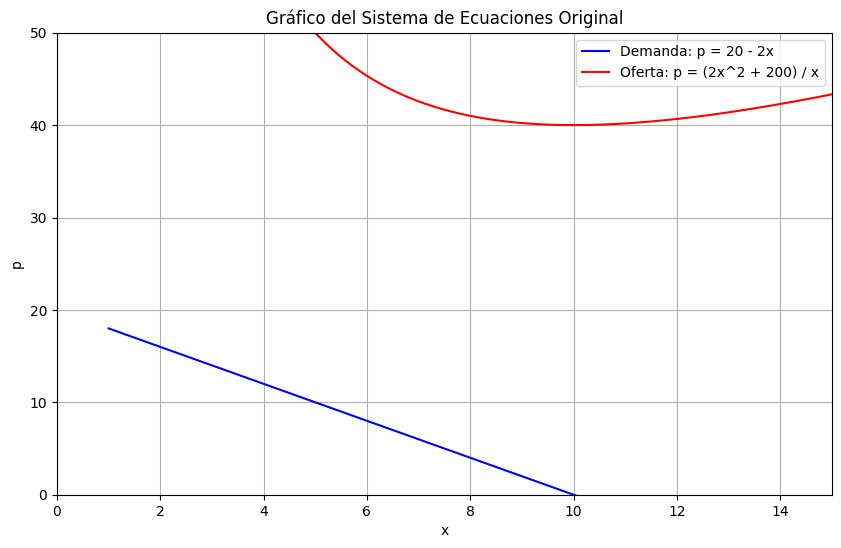

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def demanda(x_val):
    return 20 - 2 * x_val

def oferta(x_val):
    if x_val == 0:
        return np.inf
    return (2 * x_val**2 + 200) / x_val

x_vals = np.linspace(1, 20, 400)

p_demanda = [demanda(xi) for xi in x_vals]
p_oferta = [oferta(xi) for xi in x_vals]


plt.figure(figsize=(10, 6))
plt.plot(x_vals, p_demanda, label='Demanda: p = 20 - 2x', color='blue')
plt.plot(x_vals, p_oferta, label='Oferta: p = (2x^2 + 200) / x', color='red')


plt.xlabel('x')
plt.ylabel('p')
plt.title('Gráfico del Sistema de Ecuaciones Original')
plt.legend()
plt.grid(True)
plt.ylim(0, 50)
plt.xlim(0, 15)
plt.show()

### Ahora con todo lo pedido, se va a hacer con las otras funciones

Funcion 2

In [7]:
def resolver_sistema(sistema, nombre_sistema):
    print(f"\n--- {nombre_sistema} ---")
    sol = sp.solve(sistema, (x, p))

    if sol:
        real_positive_solutions = []
        all_solutions_complex = True

        for s_x, s_p in sol:
            if s_x.is_real and s_p.is_real:
                all_solutions_complex = False
                if s_x > 0 and s_p > 0:
                    real_positive_solutions.append((s_x, s_p))

        if real_positive_solutions:
            print("Equilibrios Reales y Positivos:", real_positive_solutions)
            return real_positive_solutions
        elif all_solutions_complex:
            print("Equilibrio: Todas las soluciones analíticas son complejas. No hay soluciones reales.")
            print("Soluciones encontradas (complejas):", sol)
            return None
        else:
            print("Equilibrio: Soluciones analíticas encontradas, pero ninguna es real y positiva.")
            print("Soluciones encontradas (incluyendo no positivas o complejas):", sol)
            return None

    else:
        print("Sin solución analítica simple. Intentando numérica...")
        try:
            sol_num = sp.nsolve(sistema, (x, p), (5, 5))
            if all(s.is_real for s in sol_num):
                if all(s > 0 for s in sol_num):
                    print("Equilibrio numérico real y positivo:", sol_num)
                    return sol_num
                else:
                    print("Equilibrio numérico real encontrado, pero no es positivo:", sol_num)
                    return None
            else:
                print("Equilibrio numérico encontrado, pero es complejo:", sol_num)
                return None
        except Exception as e:
            print(f"Error: Ajustar punto inicial o no se encontró solución numérica real. {e}")
            return None

sistema2 = [
    x - (p**2 - 10),
    p + x - 20
]

resultado = resolver_sistema(sistema2, "sistema2")


--- sistema2 ---
Equilibrios Reales y Positivos: [(15, 5)]


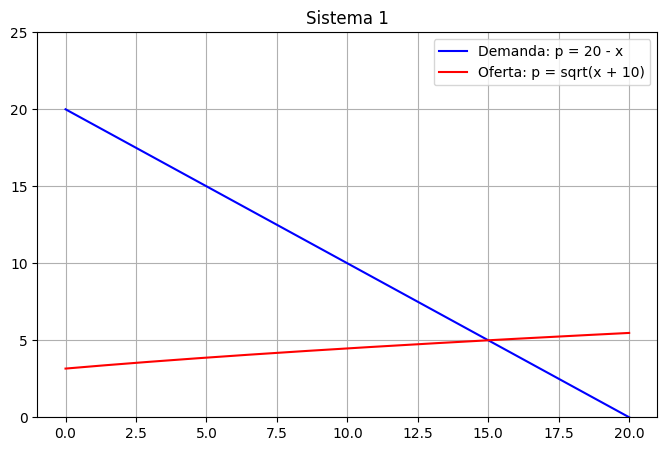

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def demanda_1(x_val):
    return 20 - x_val

def oferta_1(x_val):
    return np.sqrt(x_val + 10)

x_vals = np.linspace(0, 20, 400)
p_dem = [demanda_1(xi) for xi in x_vals]
p_ofe = [oferta_1(xi) for xi in x_vals]

plt.figure(figsize=(8, 5))
plt.plot(x_vals, p_dem, label='Demanda: p = 20 - x', color='blue')
plt.plot(x_vals, p_ofe, label='Oferta: p = sqrt(x + 10)', color='red')
plt.title('Sistema 1')
plt.legend(); plt.grid(True); plt.ylim(0, 25); plt.show()

Funcion 3

In [13]:
def resolver_sistema(sistema, nombre_sistema):
    print(f"\n--- {nombre_sistema} ---")
    sol = sp.solve(sistema, (x, p))

    if sol:
        real_positive_solutions = []
        all_solutions_complex = True

        # Modificación para manejar el formato de salida de sp.solve (lista de diccionarios)
        # Aseguramos que sol sea una lista de diccionarios para consistencia
        if isinstance(sol, dict): # Si sp.solve devuelve un solo diccionario
            sol = [sol]
        elif not isinstance(sol, list): # Si devuelve un solo objeto (e.g., Symbol), lo envolvemos
            sol = [sol]

        for s_item in sol:
            # Si el elemento es un diccionario, extraemos x y p
            if isinstance(s_item, dict):
                s_x = s_item.get(x)
                s_p = s_item.get(p)
            # Si el elemento es una tupla, lo desempaquetamos (formato original esperado)
            elif isinstance(s_item, (tuple, list)) and len(s_item) == 2:
                s_x, s_p = s_item
            else:
                # Si no es un diccionario ni una tupla/lista de 2, es un formato inesperado
                continue # Saltamos este elemento o manejamos el error apropiadamente

            if s_x is not None and s_p is not None and s_x.is_real and s_p.is_real:
                all_solutions_complex = False
                if s_x > 0 and s_p > 0:
                    real_positive_solutions.append((s_x, s_p))

        if real_positive_solutions:
            print("Equilibrios Reales y Positivos:", real_positive_solutions)
            return real_positive_solutions
        elif all_solutions_complex:
            print("Equilibrio: Todas las soluciones analíticas son complejas. No hay soluciones reales.")
            print("Soluciones encontradas (complejas):", sol)
            return None
        else:
            print("Equilibrio: Soluciones analíticas encontradas, pero ninguna es real y positiva.")
            print("Soluciones encontradas (incluyendo no positivas o complejas):", sol)
            return None

    else:
        print("Sin solución analítica simple. Intentando numérica...")
        try:
            sol_num = sp.nsolve(sistema, (x, p), (5, 5))
            if all(s.is_real for s in sol_num):
                if all(s > 0 for s in sol_num):
                    print("Equilibrio numérico real y positivo:", sol_num)
                    return sol_num
                else:
                    print("Equilibrio numérico real encontrado, pero no es positivo:", sol_num)
                    return None
            else:
                print("Equilibrio numérico encontrado, pero es complejo:", sol_num)
                return None
        except Exception as e:
            print(f"Error: Ajustar punto inicial o no se encontró solución numérica real. {e}")
            return None

sistema3 = [
    x + 180*p - 2160,
    300*p - x - 2400
]

resultado = resolver_sistema(sistema3, "sistema3")


--- sistema3 ---
Equilibrios Reales y Positivos: [(450, 19/2)]


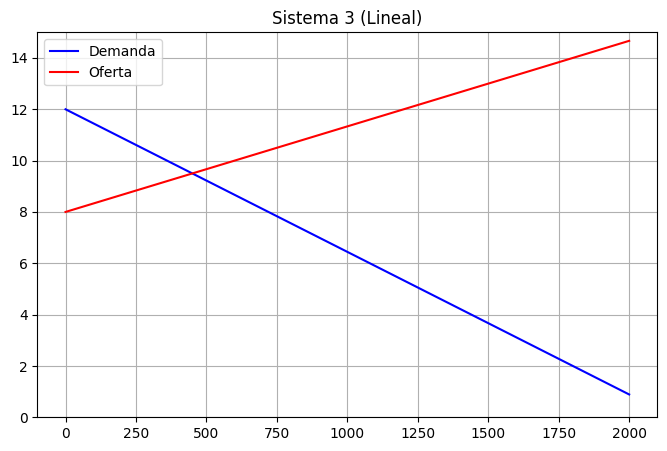

In [14]:
def demanda_2(x_val):
    return (2160 - x_val) / 180

def oferta_2(x_val):
    return (x_val + 2400) / 300

x_vals = np.linspace(0, 2000, 400)
p_dem = [demanda_2(xi) for xi in x_vals]
p_ofe = [oferta_2(xi) for xi in x_vals]

plt.figure(figsize=(8, 5))
plt.plot(x_vals, p_dem, label='Demanda', color='blue')
plt.plot(x_vals, p_ofe, label='Oferta', color='red')
plt.title('Sistema 3 (Lineal)')
plt.legend(); plt.grid(True); plt.ylim(0, 15); plt.show()

Funcion 4

In [15]:
def resolver_sistema(sistema, nombre_sistema):
    print(f"\n--- {nombre_sistema} ---")
    sol = sp.solve(sistema, (x, p))

    if sol:
        real_positive_solutions = []
        all_solutions_complex = True

        for s_x, s_p in sol:
            if s_x.is_real and s_p.is_real:
                all_solutions_complex = False
                if s_x > 0 and s_p > 0:
                    real_positive_solutions.append((s_x, s_p))

        if real_positive_solutions:
            print("Equilibrios Reales y Positivos:", real_positive_solutions)
            return real_positive_solutions
        elif all_solutions_complex:
            print("Equilibrio: Todas las soluciones analíticas son complejas. No hay soluciones reales.")
            print("Soluciones encontradas (complejas):", sol)
            return None
        else:
            print("Equilibrio: Soluciones analíticas encontradas, pero ninguna es real y positiva.")
            print("Soluciones encontradas (incluyendo no positivas o complejas):", sol)
            return None

    else:
        print("Sin solución analítica simple. Intentando numérica...")
        try:
            sol_num = sp.nsolve(sistema, (x, p), (5, 5))
            if all(s.is_real for s in sol_num):
                if all(s > 0 for s in sol_num):
                    print("Equilibrio numérico real y positivo:", sol_num)
                    return sol_num
                else:
                    print("Equilibrio numérico real encontrado, pero no es positivo:", sol_num)
                    return None
            else:
                print("Equilibrio numérico encontrado, pero es complejo:", sol_num)
                return None
        except Exception as e:
            print(f"Error: Ajustar punto inicial o no se encontró solución numérica real. {e}")
            return None

sistema4 = [
    x - (1/2 * p + 2),
    (p + 6) * x - 24
]

resultado = resolver_sistema(sistema4, "sistema4")


--- sistema4 ---
Equilibrios Reales y Positivos: [(3.00000000000000, 2.00000000000000)]


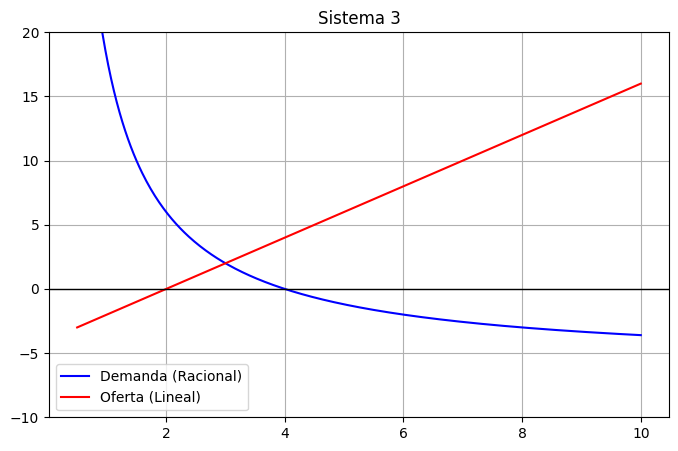

In [16]:
def demanda_3(x_val):
    if x_val == 0: return np.inf
    return (24 / x_val) - 6

def oferta_3(x_val):
    return 2 * x_val - 4

x_vals = np.linspace(0.5, 10, 400)
p_dem = [demanda_3(xi) for xi in x_vals]
p_ofe = [oferta_3(xi) for xi in x_vals]

plt.figure(figsize=(8, 5))
plt.plot(x_vals, p_dem, label='Demanda (Racional)', color='blue')
plt.plot(x_vals, p_ofe, label='Oferta (Lineal)', color='red')
plt.title('Sistema 3')
plt.axhline(0, color='black', lw=1)
plt.legend(); plt.grid(True); plt.ylim(-10, 20); plt.show()